# Librerías

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore


import os
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np 
from pathlib import Path

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
import tarfile
import urllib.request

# pd.reset_option('display.max_rows')
# pd.set_option('display.max_rows', None)

# Funciones

# Funciones Comparativas para Gráficos

In [2]:
# Mejor opción para comparación de gráfico de disperción Correlación
# 1) Gráfico inicial, datos reales sin modificación
# 2) Gráfico con datos peculiares (lineas) en la primer gráfica
# 3) Gráfico sin los datos peculiares y supuesto resultado final del gráfico de dispersión

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def compare_three_views(
    df: pd.DataFrame,
    highlight_values: list[float],
    x_col: str = "median_income",
    y_col: str = "median_house_value"
) -> None:
    """
    Muestra tres gráficos de dispersión lado a lado:
    1. Todos los datos.
    2. Datos con ciertos valores resaltados.
    3. Datos excluyendo esos valores.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    highlight_values : list[float]
        Lista de valores a resaltar o eliminar del eje Y.

    x_col : str
        Columna para el eje X (por defecto: 'median_income').

    y_col : str
        Columna para el eje Y (por defecto: 'median_house_value').
    """

    # Filtrar puntos a resaltar y los excluidos
    highlight = df[df[y_col].isin(highlight_values)]
    excluded_df = df[~df[y_col].isin(highlight_values)]

    # Crear figura con tres subgráficos
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # 1. Todos los datos
    df.plot(kind="scatter", x=x_col, y=y_col,
            alpha=0.1, grid=True, ax=axes[0])
    axes[0].set_title("Todos los datos")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)

    # 2. Con puntos destacados
    axes[1].scatter(df[x_col], df[y_col],
                    alpha=0.1, label="All data", color="blue")
    axes[1].scatter(highlight[x_col], highlight[y_col],
                    color="red", label="Valores resaltados", edgecolor="black")
    # Líneas horizontales
    lines = np.linspace(df[y_col].min(), df[y_col].max(), 51)
    for y in lines:
        axes[1].axhline(y=y, color="gray", linestyle="--", linewidth=0.4)
    axes[1].set_title("Con valores resaltados")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel("")

    # 3. Excluyendo los valores
    excluded_df.plot(kind="scatter", x=x_col, y=y_col,
                     alpha=0.1, grid=True, color="green", ax=axes[2])
    axes[2].set_title("Valores excluidos")
    axes[2].set_xlabel(x_col)
    axes[2].set_ylabel("")

    plt.tight_layout()
    plt.show()


In [3]:
# Gráfico doble, para comparación
# Original y gráfico final
import matplotlib.pyplot as plt
import pandas as pd

def compare_exclusion_effect(
    df: pd.DataFrame,
    exclude_values: list[float],
    x_col: str = "median_income",
    y_col: str = "median_house_value"
) -> None:
    """
    Muestra dos gráficos de dispersión lado a lado:
    - Izquierda: todos los datos.a
    - Derecha: sin los valores de y_col indicados en exclude_values.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    exclude_values : list[float]
        Lista de valores a excluir de y_col.

    x_col : str
        Columna para el eje X (por defecto 'median_income').

    y_col : str
        Columna para el eje Y (por defecto 'median_house_value').
    """

    # Crear subconjunto sin los valores excluidos
    filtered_df = df[~df[y_col].isin(exclude_values)]

    # Crear figura con dos ejes lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Gráfico 1: todos los datos
    df.plot(kind="scatter", x=x_col, y=y_col,
            alpha=0.1, grid=True, ax=axes[0])
    axes[0].set_title("Todos los datos")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)

    # Gráfico 2: sin valores excluidos
    filtered_df.plot(kind="scatter", x=x_col, y=y_col,
                     alpha=0.1, grid=True, ax=axes[1], color="green")
    axes[1].set_title(f"Sin valores: {exclude_values}")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel("")  # Oculta etiqueta duplicada

    plt.tight_layout()
    plt.show()


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_excluding_values(
    df: pd.DataFrame,
    exclude_values: list[float],
    x_col: str = "median_income",
    y_col: str = "median_house_value"
) -> None:
    """
    Grafica un scatter plot excluyendo los valores indicados de la columna y_col.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    exclude_values : list[float]
        Lista de valores a excluir de y_col.

    x_col : str
        Columna para el eje X (por defecto 'median_income').

    y_col : str
        Columna para el eje Y (por defecto 'median_house_value').
    """

    # Filtrar registros cuyo valor en y_col NO esté en la lista de exclusión
    filtered_df = df[~df[y_col].isin(exclude_values)]

    # Graficar
    filtered_df.plot(kind="scatter", x=x_col, y=y_col,
                     alpha=0.1, grid=True, figsize=(10, 6))
    plt.title(f"Distribución de {y_col} excluyendo valores específicos")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def compare_value_distribution(
    df: pd.DataFrame,
    highlight_values: list[float],
    x_col: str | None = None,
    y_col: str | None = None
) -> None:
    """
    Muestra dos gráficos de dispersión para comparar la distribución de valores entre dos columnas.

    Si no se especifican x_col ni y_col, se tomarán automáticamente
    las dos primeras columnas numéricas del DataFrame.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    highlight_values : list[float]
        Lista de valores en y_col que se desean resaltar visualmente.

    x_col : str | None
        Nombre de la columna a usar como eje X (opcional).

    y_col : str | None
        Nombre de la columna a usar como eje Y (opcional).
    """

    # Seleccionar columnas numéricas si no se especificaron
    if x_col is None or y_col is None:
        numeric_cols = df.select_dtypes(include=np.number).columns
        if len(numeric_cols) < 2:
            raise ValueError("El DataFrame debe tener al menos dos columnas numéricas.")
        x_col = x_col or numeric_cols[0]
        y_col = y_col or numeric_cols[1]

    # Primer gráfico: general
    df.plot(kind="scatter", x=x_col, y=y_col,
            alpha=0.1, grid=True, figsize=(10, 6))
    plt.title(f"Distribución general de {y_col} en función de {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

    # Segundo gráfico: con puntos destacados
    highlight = df[df[y_col].isin(highlight_values)]

    plt.figure(figsize=(10, 6))
    plt.scatter(df[x_col], df[y_col],
                alpha=0.1, label="All data", color="blue")
    plt.scatter(highlight[x_col], highlight[y_col],
                color="red", label="Highlighted values", edgecolor="black")

    # Líneas horizontales en el eje Y
    y_min = df[y_col].min()
    y_max = df[y_col].max()
    lines = np.linspace(y_min, y_max, 51)

    for y in lines:
        plt.axhline(y=y, color="gray", linestyle="--", linewidth=0.6)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True)
    plt.legend()
    plt.title(f"Resaltado de valores específicos en {y_col}")
    plt.show()


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def compare_value_distribution_default(
    df: pd.DataFrame,
    highlight_values: list[float],
    x_col: str = "median_income",
    y_col: str = "median_house_value"
) -> None:
    """
    Muestra dos gráficos de dispersión para comparar la distribución de valores entre dos columnas.

    1. Un gráfico general con todos los datos.
    2. Un gráfico donde se resaltan ciertos valores específicos de la variable en el eje Y.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    highlight_values : list[float]
        Lista de valores en y_col que se desean resaltar visualmente.

    x_col : str
        Nombre de la columna a usar como eje X (por defecto: 'median_income').

    y_col : str
        Nombre de la columna a usar como eje Y (por defecto: 'median_house_value').
    """

    # Primer gráfico: general
    df.plot(kind="scatter", x=x_col, y=y_col,
            alpha=0.1, grid=True, figsize=(10, 6))
    plt.title(f"Distribución general de {y_col} en función de {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

    # Segundo gráfico: con puntos destacados
    all_points = df
    highlight = df[df[y_col].isin(highlight_values)]

    plt.figure(figsize=(10, 6))
    plt.scatter(all_points[x_col], all_points[y_col],
                alpha=0.1, label="All data", color="blue")

    plt.scatter(highlight[x_col], highlight[y_col],
                color="red", label="Highlighted values", edgecolor="black")

    # Líneas horizontales distribuidas en y_col
    y_min = df[y_col].min()
    y_max = df[y_col].max()
    lines = np.linspace(y_min, y_max, 51)

    for y in lines:
        plt.axhline(y=y, color="gray", linestyle="--", linewidth=0.6)

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True)
    plt.legend()
    plt.title(f"Resaltado de valores específicos en {y_col}")
    plt.show()


In [7]:
def remove_house_value_outliers(df: pd.DataFrame, values_to_remove: list, column: str ="median_house_value"):
    """
    Elimina registros del DataFrame donde la columna especificada
    toma alguno de los valores indicados en la lista `values_to_remove`.

    Parámetros:
    ----------
    df : pandas.DataFrame
        El DataFrame original.

    values_to_remove : list
        Lista de valores que deben ser eliminados de la columna objetivo.

    column : str
        Nombre de la columna sobre la cual aplicar el filtro. Por defecto es 'median_house_value'.

    Retorna:
    -------
    pandas.DataFrame
        Una copia del DataFrame sin los valores especificados.
    """
    filtered_df = df[~df[column].isin(values_to_remove)].copy()
    return filtered_df


# Funciones matemáticas

In [8]:
def rmse(X, y, h):
    """
    Calcula el RMSE. root mean square error

    Parámetros:
    -----------1 
    X : array-like
        Datos de entrada (puede ser 1D o 2D según el modelo).
    y : array-like
        Valores verdaderos.
    h : función
        Función de predicción que acepta X como entrada.

    Retorna:
    --------
    rmse : float
        Root Mean Square Error.
    """
    m = len(y)
    predictions = h(X)
    error = predictions - y
    mse = np.sum(error ** 2) / m
    return np.sqrt(mse)


In [9]:
# X son valores simples
X = np.array([1, 2, 3, 4, 5])
y = np.array([1.2, 1.9, 3.1, 3.8, 5.2])

# función h cualquiera
def h(X):
    return 0.95 * X + 0.1

# RMSE
resultado = rmse(X, y, h)
print(f"RMSE: {resultado}")

RMSE: 0.1936491673103711


In [10]:
import numpy as np

def mae(X, y, h):
    """
    Calcula el MAE. Mean Absolute Error

    Parámetros:
    -----------
    X : array-like
        Datos de entrada (puede ser 1D o 2D según el modelo).
    y : array-like
        Valores verdaderos.
    h : función
        Función de predicción que acepta X como entrada.

    Retorna:
    --------
    mae : float
        Mean Absolute Error.
    """
    m = len(y)
    predictions = h(X)
    error = np.abs(predictions - y)
    return np.sum(error) / m


In [11]:
# Supongamos X y y
X = np.array([1, 2, 3, 4, 5])
y = np.array([1.2, 1.9, 3.1, 3.8, 5.2])

# Definimos una función de predicción simple
def h(X):
    return 0.95 * X + 0.1

# Calculamos el MAE
resultado = mae(X, y, h)
print(f"MAE: {resultado}")

MAE: 0.1700000000000002


# Funciones DataFrame

In [12]:
import pandas as pd
import numpy as np

def generate_arithmetic_correlations(
    df: pd.DataFrame,
    target_col: str,
    operations: list = ['div'],
    drop_na: bool = True,
    round_decimals: int = 6
) -> pd.DataFrame:
    """
    Genera atributos combinados entre columnas numéricas usando operaciones aritméticas,
    calcula su correlación con la columna objetivo y devuelve una tabla ordenada.

    Parámetros:
    ----------
    df : pd.DataFrame
        DataFrame de entrada.

    target_col : str
        Nombre de la columna objetivo con la que calcular la correlación.

    operations : list
        Lista de operaciones a aplicar: puede incluir 'div', 'sub', 'add', 'mul'.

    drop_na : bool
        Si True, elimina combinaciones que contengan NaN o inf (por división por cero, etc).

    round_decimals : int
        Número de decimales para redondear las correlaciones en el resultado.

    Retorna:
    -------
    pd.DataFrame con las columnas:
        - 'attribute': nombre del atributo generado.
        - 'operation': tipo de operación aplicada.
        - 'correlation': correlación con la columna objetivo.
    """
    if target_col not in df.columns:
        raise ValueError(f"La columna objetivo '{target_col}' no existe en el DataFrame.")

    numeric_cols = df.select_dtypes(include=np.number).columns
    results = []

    for col1 in numeric_cols:
        for col2 in numeric_cols:
            if col1 == col2:
                continue
            for op in operations:
                attr_name = f"{col1}_{op}_{col2}"
                try:
                    if op == 'div':
                        with np.errstate(divide='ignore', invalid='ignore'):
                            new_col = df[col1] / df[col2]
                    elif op == 'sub':
                        new_col = df[col1] - df[col2]
                    elif op == 'add':
                        new_col = df[col1] + df[col2]
                    elif op == 'mul':
                        new_col = df[col1] * df[col2]
                    else:
                        continue
                except Exception:
                    continue

                if drop_na:
                    valid_mask = new_col.replace([np.inf, -np.inf], np.nan).notna() & df[target_col].notna()
                    if valid_mask.sum() < 2:
                        continue
                    corr = np.corrcoef(new_col[valid_mask], df[target_col][valid_mask])[0, 1]
                else:
                    corr = new_col.corr(df[target_col])

                if pd.notna(corr):
                    results.append({
                        "attribute": attr_name,
                        "operation": op,
                        "correlation": round(corr, round_decimals)
                    })

    result_df = pd.DataFrame(results).sort_values("correlation", key=np.abs, ascending=False).reset_index(drop=True)
    return result_df

# Demostración pendiente del DataFrame 'housing'. Esta función está lista para ser utilizada.



In [13]:
import pandas as pd

def remove_specific_values(
    df: pd.DataFrame,
    column: str,
    values_to_remove: list[float]
) -> pd.DataFrame:
    """
    Elimina del DataFrame las filas donde la columna especificada
    contiene alguno de los valores indicados.

    Parámetros:
    ----------
    df : pd.DataFrame
        DataFrame original.

    column : str
        Nombre de la columna sobre la que aplicar el filtro.

    values_to_remove : list[float]
        Lista de valores que deben eliminarse de esa columna.

    Retorna:
    -------
    pd.DataFrame
        Una copia del DataFrame sin los registros filtrados.
    """
    if column not in df.columns:
        raise ValueError(f"La columna '{column}' no existe en el DataFrame.")
    
    return df[~df[column].isin(values_to_remove)].copy()


In [14]:
import pandas as pd
import numpy as np

def compare_dataframes(df1, df2, float_tol=1e-6, export_path=None):
    """
    Compara dos DataFrames en estructura, tipos de datos, contenido y estadísticas.

    Parámetros
    -----------
    df1 : pandas.DataFrame
        Primer DataFrame a comparar.
    df2 : pandas.DataFrame
        Segundo DataFrame a comparar.
    float_tol : float, opcional (default=1e-6)
        Tolerancia para comparar diferencias en columnas numéricas de punto flotante.
    export_path : str o None
        Ruta opcional para exportar el reporte final a Excel (si se desea guardar).

    Retorno
    --------
    report : dict
        Diccionario con los distintos reportes de comparación.
    """

    report = {}

    # 1. Comparación de dimensiones
    dims = {
        'Rows df1': df1.shape[0],
        'Rows df2': df2.shape[0],
        'Cols df1': df1.shape[1],
        'Cols df2': df2.shape[1]
    }
    report['dimensions'] = pd.Series(dims)

    # 2. Comparación de columnas
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    report['common_columns'] = list(cols1 & cols2)
    report['only_in_df1'] = list(cols1 - cols2)
    report['only_in_df2'] = list(cols2 - cols1)

    # 3. Comparación de tipos de datos
    common_cols = cols1 & cols2
    dtype_mismatches = {}
    for col in common_cols:
        if df1[col].dtype != df2[col].dtype:
            dtype_mismatches[col] = (df1[col].dtype, df2[col].dtype)
    report['dtype_mismatches'] = dtype_mismatches

    # 4. Comparación de valores exactos (índices coincidentes)
    exact_differences = []
    inter_idx = df1.index.intersection(df2.index)

    for col in common_cols:
        s1 = df1.loc[inter_idx, col]
        s2 = df2.loc[inter_idx, col]

        # Si es numérico usamos tolerancia
        if pd.api.types.is_numeric_dtype(s1):
            unequal = ~np.isclose(s1.fillna(0), s2.fillna(0), atol=float_tol)
        else:
            # Evitamos el FutureWarning: convertimos a object antes de fillna()
            s1_filled = s1.astype(object).fillna("__MISSING__")
            s2_filled = s2.astype(object).fillna("__MISSING__")
            unequal = s1_filled != s2_filled

        count_diff = unequal.sum()
        if count_diff > 0:
            exact_differences.append((col, count_diff))

    report['exact_differences'] = exact_differences

    # 5. Comparación estadística (solo columnas numéricas comunes)
    stats_summary = []

    for col in common_cols:
        if pd.api.types.is_numeric_dtype(df1[col]):
            stats1 = df1[col].describe()
            stats2 = df2[col].describe()
            combined = pd.DataFrame({'df1': stats1, 'df2': stats2})
            combined['diff'] = combined['df1'] - combined['df2']
            combined = combined.round(4)
            stats_summary.append((col, combined))

    report['statistics'] = stats_summary

    # 6. Exportación opcional a Excel
    if export_path is not None:
        with pd.ExcelWriter(export_path) as writer:
            pd.DataFrame(report['dimensions']).to_excel(writer, sheet_name='Dimensions')
            if dtype_mismatches:
                pd.DataFrame(dtype_mismatches, index=["df1_dtype", "df2_dtype"]).T.to_excel(writer, sheet_name='Dtype_Mismatches')
            if exact_differences:
                pd.DataFrame(report['exact_differences'], columns=['Column', 'Diff_Count']).to_excel(writer, sheet_name='Exact_Differences')
            for col, stats in report['statistics']:
                # Limitar el nombre de la hoja a 31 caracteres por restricción de Excel
                sheet_name = f'Stats_{col[:25]}'
                stats.to_excel(writer, sheet_name=sheet_name)

    return report


In [15]:
def split_balance_report(df, target_column, test_size=0.2, random_state=42):
    """
    Genera un reporte comparativo de balance de clases entre el conjunto completo
    y los subconjuntos de prueba generados por partición aleatoria y partición estratificada.

    El objetivo es cuantificar las diferencias de distribución de clases entre:
    - El dataset original.
    - Un test set generado por partición aleatoria.
    - Un test set generado por partición estratificada.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame que contiene los datos completos.
    target_column : str
        Nombre de la columna categórica sobre la cual se evaluará el balance.
    test_size : float, optional (default=0.2)
        Proporción del dataset que será asignado al conjunto de prueba.
    random_state : int, optional (default=42)
        Semilla para asegurar reproducibilidad en la generación aleatoria.

    Returns
    -------
    report : pandas.DataFrame
        Tabla resumen que contiene:
            - Porcentaje de cada clase en el dataset completo (Overall %).
            - Porcentaje de cada clase en el test set aleatorio (Random %).
            - Porcentaje de cada clase en el test set estratificado (Stratified %).
            - Error absoluto de cada partición respecto al dataset original 
              (Rand. Error %, Strat. Error %).

    Notes
    -----
    Esta función es útil para evaluar el impacto de distintos métodos de partición
    en problemas de clasificación, especialmente cuando existe desbalance de clases.

    Example
    -------
    >>> split_balance_report(df, target_column='Income Category')
    """
    
    from sklearn.model_selection import train_test_split
    
    # Original
    overall = df[target_column].value_counts(normalize=True).sort_index() * 100

    # Random split
    _, test_rand = train_test_split(df, test_size=test_size, random_state=random_state)
    rand = test_rand[target_column].value_counts(normalize=True).sort_index() * 100

    # Stratified split
    _, test_strat = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_column])
    strat = test_strat[target_column].value_counts(normalize=True).sort_index() * 100

    # Tabla
    report = pd.DataFrame({
        'Overall %': overall,
        'Stratified %': strat,
        'Random %': rand
    })
    report['Strat. Error %'] = (report['Stratified %'] - report['Overall %']).round(2)
    report['Rand. Error %'] = (report['Random %'] - report['Overall %']).round(2)
    return report.round(2)



In [16]:
#def income_cat_proportions(data):
#    return data["income_cat"].value_counts() / len(data)
#
#train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
#
#compare_props = pd.DataFrame({
#    "Overall": income_cat_proportions(housing),
#    "Stratified": income_cat_proportions(strat_train_set_n),
#    "Random": income_cat_proportions(test_set),
#}).sort_index()
#compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
#compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
#
##compare_props

In [17]:
# split_balance_report(strat_test_set, "income_cat")

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

def compare_category_proportions_full(
    df: pd.DataFrame,
    column: str,
    test_size: float = 0.2,
    random_state: int = 42
) -> pd.DataFrame:
    """
    Divide el DataFrame original en dos particiones (aleatoria y estratificada),
    luego compara las proporciones de la columna categórica seleccionada en los tres conjuntos:
    original, estratificado y aleatorio.

    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame completo original.
    column : str
        Nombre de la columna categórica a comparar.
    test_size : float, optional
        Proporción del conjunto de prueba. Default es 0.2.
    random_state : int, optional
        Semilla aleatoria para reproducibilidad. Default es 42.

    Retorna
    -------
    pd.DataFrame
        Tabla con proporciones de clases y errores relativos en splits aleatorios y estratificados.
    """

    # División aleatoria
    train_set, test_set = train_test_split(df, test_size=test_size, random_state=random_state)

    # División estratificada
    strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for strat_train_idx, strat_test_idx in strat_split.split(df, df[column]):
        strat_test_set = df.iloc[strat_test_idx]

    # Función auxiliar para proporciones
    def proportions(data):
        return data[column].value_counts(normalize=True)

    # Construir la tabla comparativa
    compare_props = pd.DataFrame({
        "Overall": proportions(df),
        "Stratified": proportions(strat_test_set),
        "Random": proportions(test_set),
    }).sort_index()

    compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100
    compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100

    return compare_props.round(2)


# 2.1 Working with Real Data

- Popular open data repositories:

    - OpenML.org

    - Kaggle.com
    
    - PapersWithCode.com
    
    - UC Irvine Machine Learning Repository
    
    - Amazon’s AWS datasets
    
    - TensorFlow datasets

- Meta portals (they list open data repositories):

    - DataPortals.org
    
    - OpenDataMonitor.eu

- Other pages listing many popular open data repositories:

    - Wikipedia’s list of machine learning datasets
    
    - Quora.com
    
    - The datasets subreddit

# 2.2 Look at the Big Picture

- Definir el problema claramente
- Enunciados y definiciones de datos


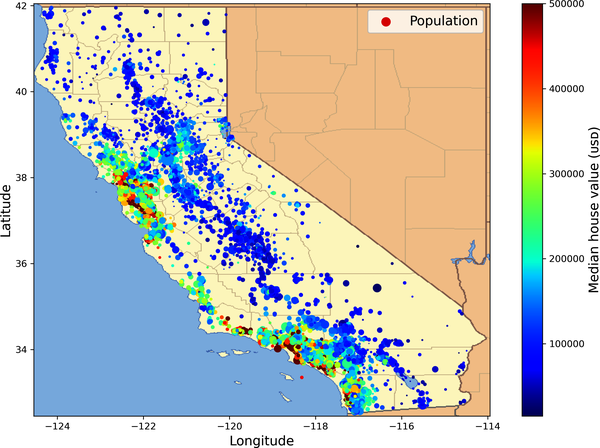

## Frame the Problem

- How does the company expect to use and benefit from this model?
- What the current solution looks like (if any)
- is it a supervised, unsupervised, semi-supervised, self-supervised, or reinforcement learning task?

## Select a Performance Measure

$$
\mathrm{RMSE}(X, h) = \sqrt{ \frac{1}{m} \sum_{i=1}^{m} \left( h\left( \mathbf{x}^{(i)} \right) - y^{(i)} \right)^2 }
$$

Ver:
```
def rmse(X, y, h):
    """
    Calcula el RMSE. root mean square error

    Parámetros:
    -----------1 
    X : array-like
        Datos de entrada (puede ser 1D o 2D según el modelo).
    y : array-like
        Valores verdaderos.
    h : función
        Función de predicción que acepta X como entrada.

    Retorna:
    --------
    rmse : float
        Root Mean Square Error.
    """
    m = len(y)
    predictions = h(X)
    error = predictions - y
    mse = np.sum(error ** 2) / m
    return np.sqrt(mse)

```

$$
\mathrm{MAE}(X, h) = \frac{1}{m} \sum_{i=1}^{m} \left| h\left( \mathbf{x}^{(i)} \right) - y^{(i)} \right|
$$

Ver:
```
def mae(X, y, h):
    """
    Calcula el MAE. Mean Absolute Error

    Parámetros:
    -----------
    X : array-like
        Datos de entrada (puede ser 1D o 2D según el modelo).
    y : array-like
        Valores verdaderos.
    h : función
        Función de predicción que acepta X como entrada.

    Retorna:
    --------
    mae : float
        Mean Absolute Error.
    """
    m = len(y)
    predictions = h(X)
    error = np.abs(predictions - y)
    return np.sum(error) / m

```

## Check the Assumptions

- Entender como será la data y los tratamientos que recibirá
- En última instancia saber que tipo de datos se van a recibir

# 2.3 Get the Data

## Running the Code Examples Using Google Colab

- Google Colab???

- https://homl.info/colab3

## Saving Your Code Changes and Your Data

- https://colab.research.google.com 

## Book Code Versus Notebook Code

## Download the Data

In [19]:
f = "datasets/housing/housing_data.csv" 
housing = pd.read_csv(f)

## Take a Quick Look at the Data Structure

In [20]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


- Each row represents one district
- There are 10 attributes (columns)

In [21]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [22]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [23]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


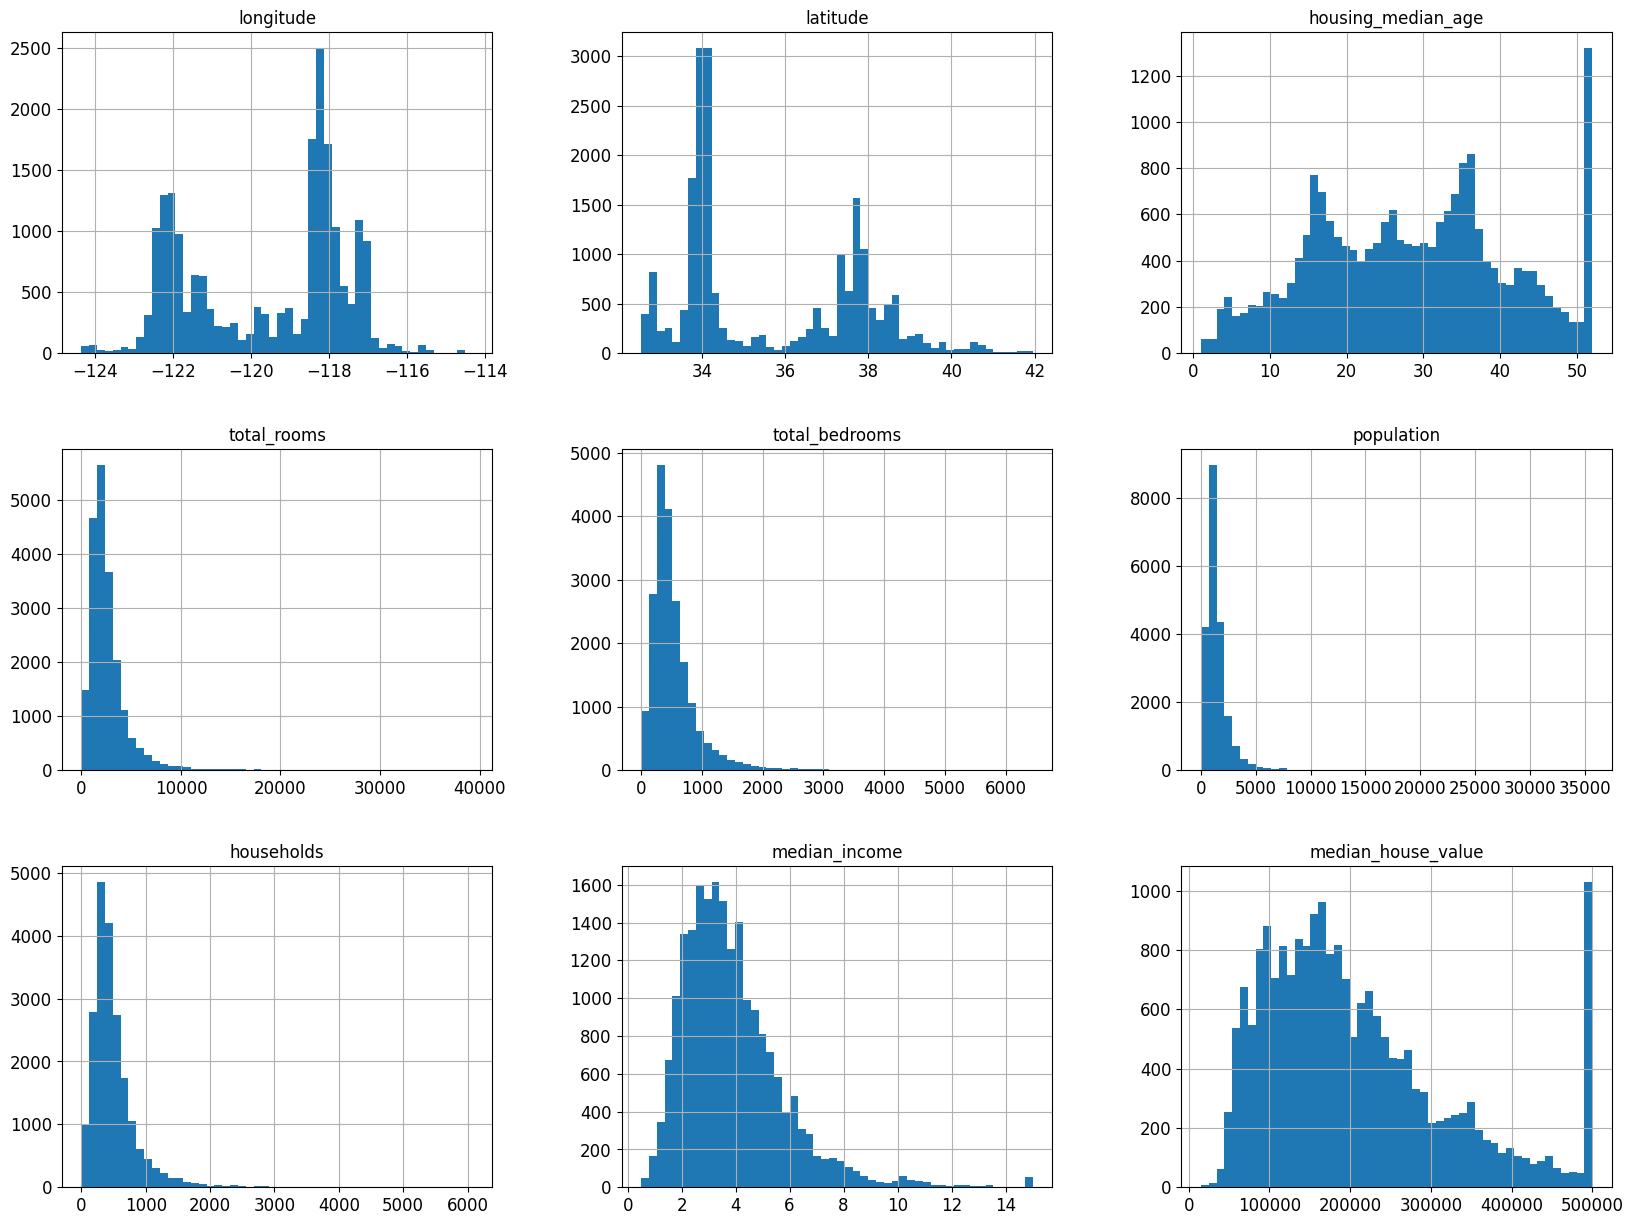

In [24]:
housing.hist(bins = 50, 
             figsize = (20, 15))
plt.show()

## Create a Test Set

- La importancia de separar el test set desde el principio.

- Implementación de separación fija reproducible.

- Técnicas de train_test_split() y StratifiedShuffleSplit().

In [25]:
# For illustration only. Sklearn has train_test_split()
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

# if you run the program again, it will generate a different test set

In [26]:
train_set, test_set = split_train_test(housing, 0.2)

In [27]:
a = len(test_set)
b = len(train_set)

print(f"train_set: {b} \\ test_set: {a}\nTotal: {b} + {a} = {a+b}\nhousing len: {len(housing)}")

train_set: 16512 \ test_set: 4128
Total: 16512 + 4128 = 20640
housing len: 20640


- This ensures that the test set will remain consistent across multiple runs
- Implementación de separación fija reproducible.

In [28]:
from zlib import crc32

def test_set_check(identifier, test_ratio):
    return crc32(np.int64(identifier)) & 0xffffffff < test_ratio * 2**32

def split_train_test_by_id(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: test_set_check(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [29]:
housing_with_id = housing.reset_index()  # adds an `index` column
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "index")

In [30]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_train_test_by_id(housing_with_id, 0.2, "id")

- Técnicas de train_test_split() y StratifiedShuffleSplit().

In [31]:
# Scikit-Learn provides a few functions to split datasets into multiple subsets in various ways. The simplest function is train_test_split()

from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [32]:
housing["income_cat"] = pd.cut(housing["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])

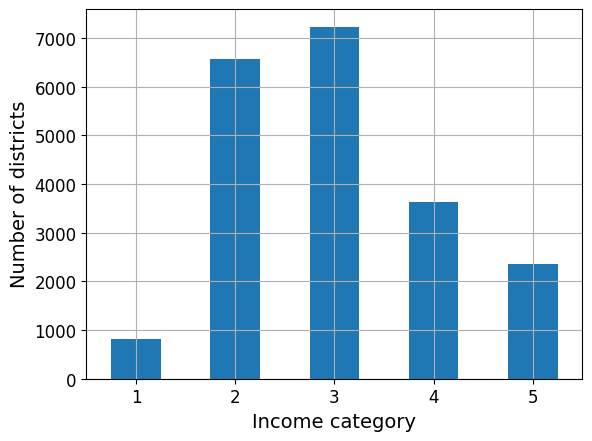

In [33]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

In [34]:
# generates n different stratified splits of the same dataset

from sklearn.model_selection import StratifiedShuffleSplit

n = 1
strat_splits = []
split = StratifiedShuffleSplit(n_splits=n, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.loc[train_index]
    strat_test_set_n = housing.loc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [35]:
strat_train_set, strat_test_set = strat_splits[0]

In [36]:
#Or, since stratified sampling is fairly common, there’s a shorter way to get a single split using the train_test_split() function with the stratify argument:

strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"], random_state=42)

In [37]:
strat_test_set["income_cat"].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [38]:
housing["income_cat"].value_counts() / len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [39]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing["income_cat"]):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

In [40]:
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(housing),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Strat. %error"] = 100 * compare_props["Stratified"] / compare_props["Overall"] - 100
compare_props["Rand. %error"] = 100 * compare_props["Random"] / compare_props["Overall"] - 100

In [41]:
(compare_props * 100).round(2)

,Overall,Stratified,Random,Strat. %error,Rand. %error
income_cat,,,,,
1,3.98,4.00,4.24,36.50,644.77
2,31.88,31.88,30.74,-1.52,-358.61
3,35.06,35.05,34.52,-1.38,-153.40
4,17.63,17.64,18.41,2.75,442.43
5,11.44,11.43,12.09,-8.47,563.08


In [42]:
test_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
20046,-122.38,40.67,10.0,2281.0,444.0,1274.0,438.0,2.2120,65600.0,INLAND,2
3024,-118.37,33.83,35.0,1207.0,207.0,601.0,213.0,4.7308,353400.0,<1H OCEAN,4
15663,-117.24,32.72,39.0,3089.0,431.0,1175.0,432.0,7.5925,466700.0,NEAR OCEAN,5
20484,-118.44,34.05,18.0,4780.0,1192.0,1886.0,1036.0,4.4674,500001.0,<1H OCEAN,3
9814,-118.44,34.18,33.0,2127.0,414.0,1056.0,391.0,4.3750,286100.0,<1H OCEAN,3


In [43]:
train_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924341,-0.110786,0.043100,0.069439,0.100706,0.056318,-0.014592,-0.043603
latitude,-0.924341,1.000000,0.012640,-0.036327,-0.069283,-0.110514,-0.073915,-0.079259,-0.146324
housing_median_age,-0.110786,0.012640,1.000000,-0.362433,-0.318544,-0.291842,-0.301198,-0.118410,0.104714
total_rooms,0.043100,-0.036327,-0.362433,1.000000,0.928199,0.851766,0.916265,0.197326,0.134060
total_bedrooms,0.069439,-0.069283,-0.318544,0.928199,1.000000,0.873484,0.979627,-0.011782,0.049993
population,0.100706,-0.110514,-0.291842,0.851766,0.873484,1.000000,0.903045,0.000883,-0.025820
households,0.056318,-0.073915,-0.301198,0.916265,0.979627,0.903045,1.000000,0.009366,0.065798
median_income,-0.014592,-0.079259,-0.118410,0.197326,-0.011782,0.000883,0.009366,1.000000,0.687013
median_house_value,-0.043603,-0.146324,0.104714,0.134060,0.049993,-0.025820,0.065798,0.687013,1.000000


In [44]:
test_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.925984,-0.097684,0.050012,0.070159,0.095969,0.051410,-0.017369,-0.054825
latitude,-0.925984,1.000000,0.005237,-0.035354,-0.058155,-0.101854,-0.060040,-0.082099,-0.135887
housing_median_age,-0.097684,0.005237,1.000000,-0.358294,-0.328100,-0.314100,-0.309858,-0.121936,0.108864
total_rooms,0.050012,-0.035354,-0.358294,1.000000,0.938942,0.879812,0.927092,0.201631,0.134702
total_bedrooms,0.070159,-0.058155,-0.328100,0.938942,1.000000,0.895123,0.980116,0.008431,0.048831
population,0.095969,-0.101854,-0.314100,0.879812,0.895123,1.000000,0.924164,0.021258,-0.019777
households,0.051410,-0.060040,-0.309858,0.927092,0.980116,0.924164,1.000000,0.027591,0.066274
median_income,-0.017369,-0.082099,-0.121936,0.201631,0.008431,0.021258,0.027591,1.000000,0.692778
median_house_value,-0.054825,-0.135887,0.108864,0.134702,0.048831,-0.019777,0.066274,0.692778,1.000000


In [45]:
housing.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [46]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [47]:
strat_train_set.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.4+ MB


# 2.4 Explore and Visualize the Data to Gain Insights

In [48]:
housing = strat_train_set.copy()

## Visualizing Geographical Data

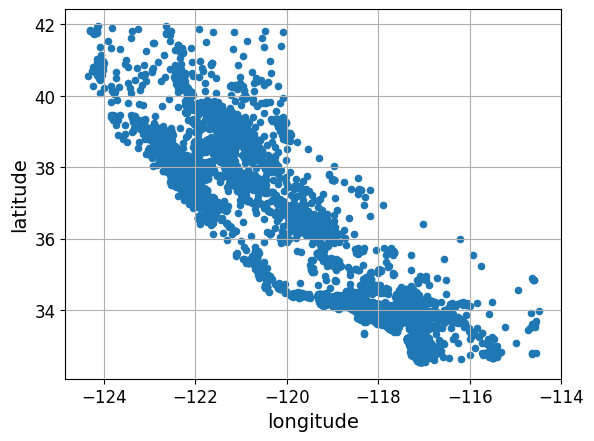

In [49]:
housing.plot(kind="scatter", 
             x = "longitude",
             y = "latitude", 
             grid = True)
plt.show()

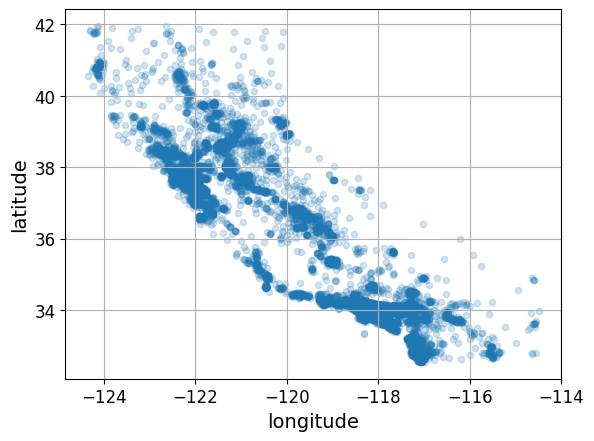

In [50]:
housing.plot(kind="scatter", 
             x="longitude", 
             y="latitude", 
             grid=True, alpha=0.2)
plt.show()

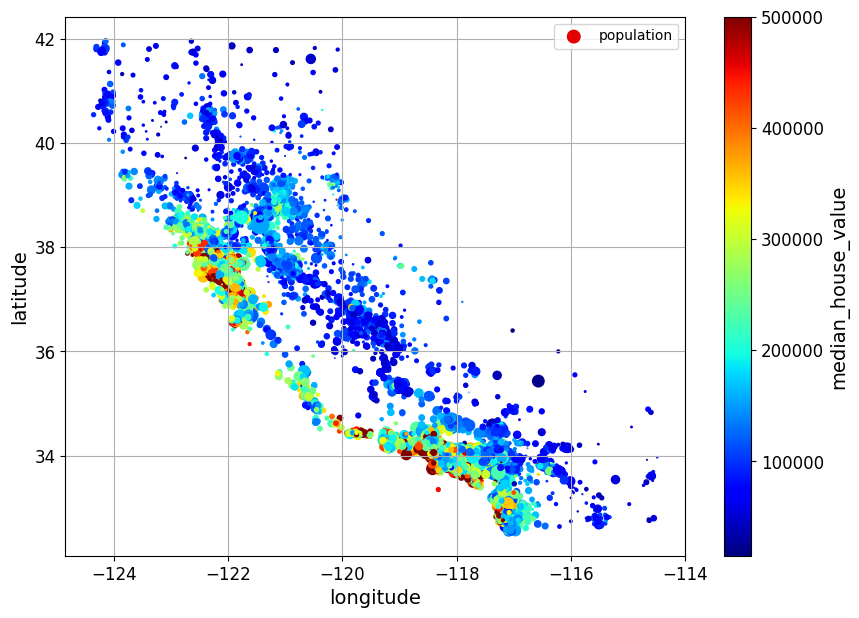

In [51]:
housing.plot(kind="scatter", 
             x="longitude", 
             y="latitude", 
             grid=True,
             s=housing["population"] / 100, 
             label="population",
             c="median_house_value", 
             cmap="jet", 
             colorbar=True,
             legend=True, 
             sharex=False, 
             figsize=(10, 7))
plt.show()

## Look for Correlations

In [52]:
corr_matrix = housing.corr(numeric_only=True)

In [53]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

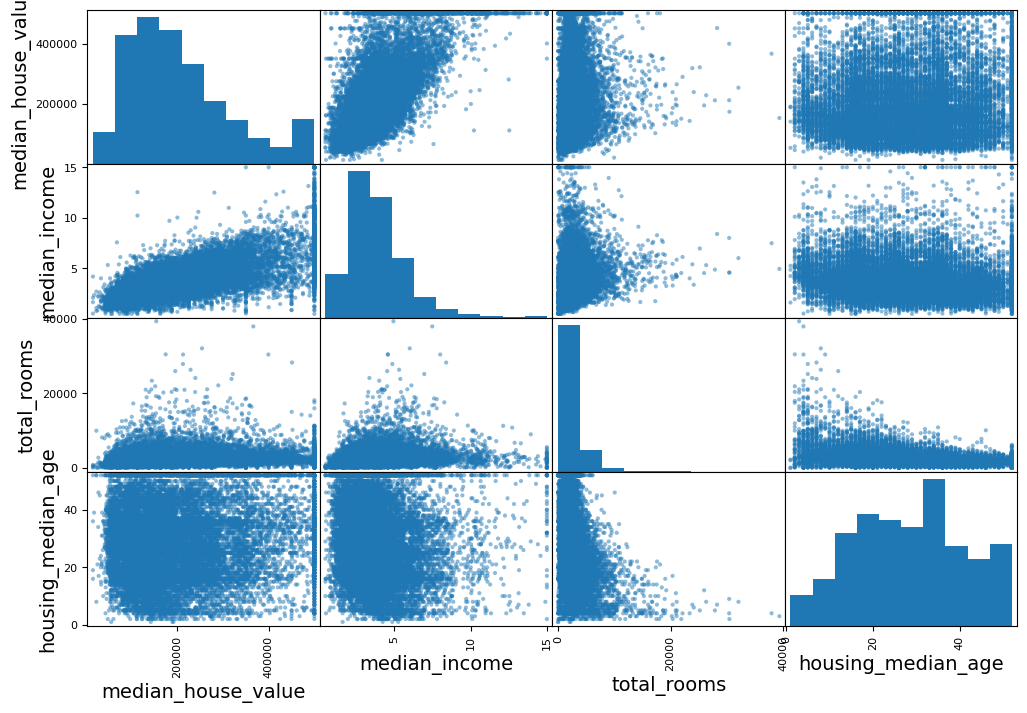

In [54]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", 
              "median_income", 
              "total_rooms",
              "housing_median_age"]
scatter_matrix(housing[attributes], 
               figsize=(12, 8))
plt.show()

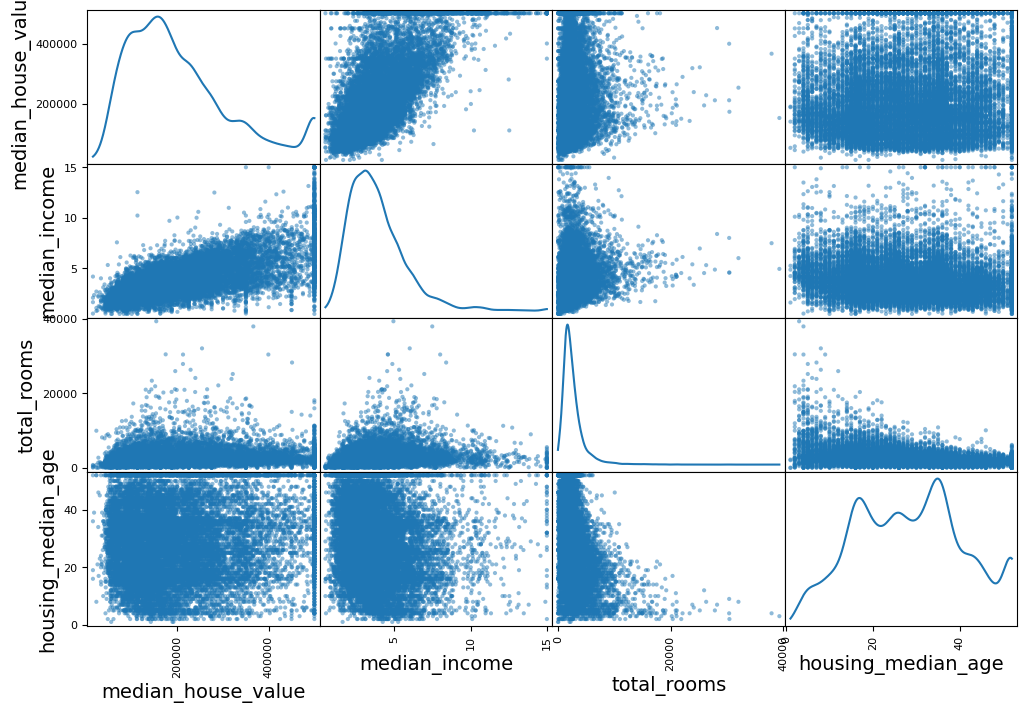

In [55]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", 
              "median_income", 
              "total_rooms", 
              "housing_median_age"]

scatter_matrix(housing[attributes], 
               figsize=(12, 8), 
               diagonal="kde")
plt.show()

In [56]:
housing["median_house_value"].max()

np.float64(500001.0)

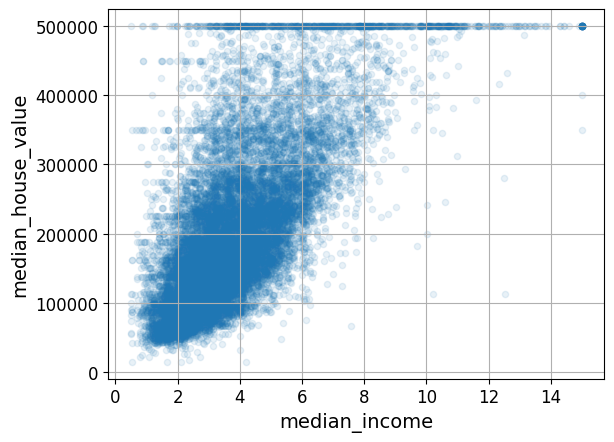

In [57]:
housing.plot(kind="scatter", x="median_income", y="median_house_value",
             alpha=0.1, grid=True)
plt.show()

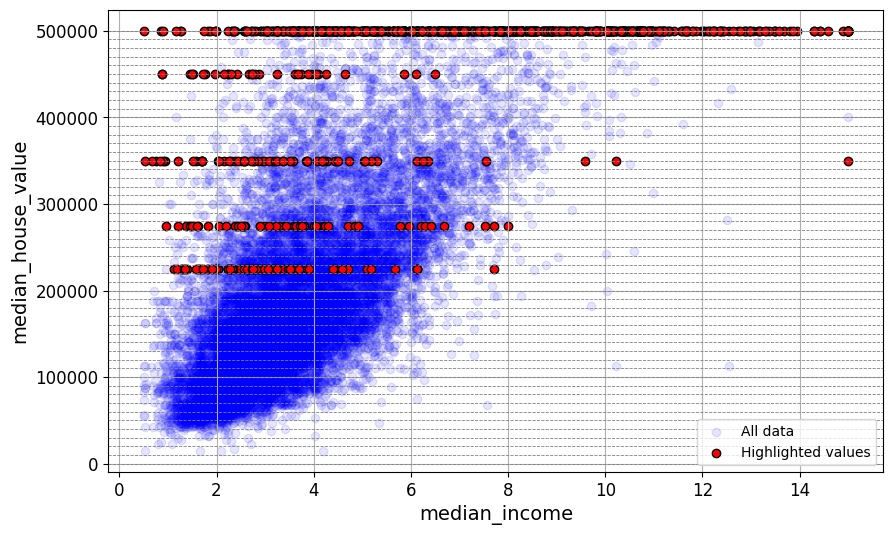

In [58]:
# Validación de datos (lineas) peculiares en el gráfico
import matplotlib.pyplot as plt
import numpy as np

# Todos los puntos
all_points = housing

# Puntos a resaltar
highlight_values = [350000, 450000, 225000, 275000, 500000, 500001]  # Se hacen pruebas para ver si son los correctos.

highlight = housing[housing["median_house_value"].isin(highlight_values)]

# Crear el gráfico base
plt.figure(figsize=(10, 6))
plt.scatter(all_points["median_income"], all_points["median_house_value"],
            alpha=0.1, label="All data", color="blue")

plt.scatter(highlight["median_income"], highlight["median_house_value"],
            color="red", label="Highlighted values", edgecolor="black")

# Agregar líneas horizontales grises (10 divisiones)
y_min = housing["median_house_value"].min()
y_max = housing["median_house_value"].max()
lines = np.linspace(0, 500000, 51)

for y in lines:
    plt.axhline(y=y, color="gray", linestyle="--", linewidth=0.6) # Se agregan las lineas grises para identificar las peculiaridades 

# Etiquetas y leyenda
plt.xlabel("median_income")
plt.ylabel("median_house_value")
plt.grid(True)
plt.legend()
plt.show()


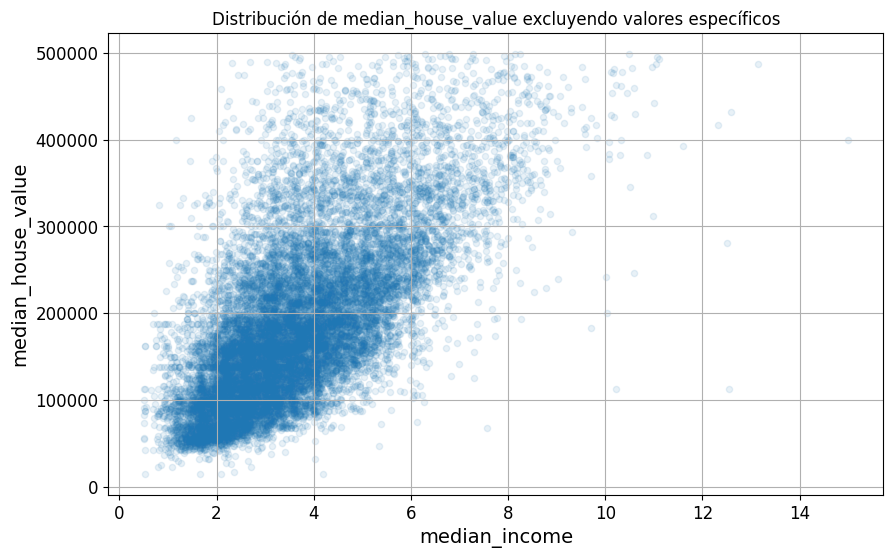

In [59]:
highlight_values = [350000, 450000, 225000, 275000, 500000, 500001]
plot_excluding_values(df=housing, exclude_values=highlight_values)

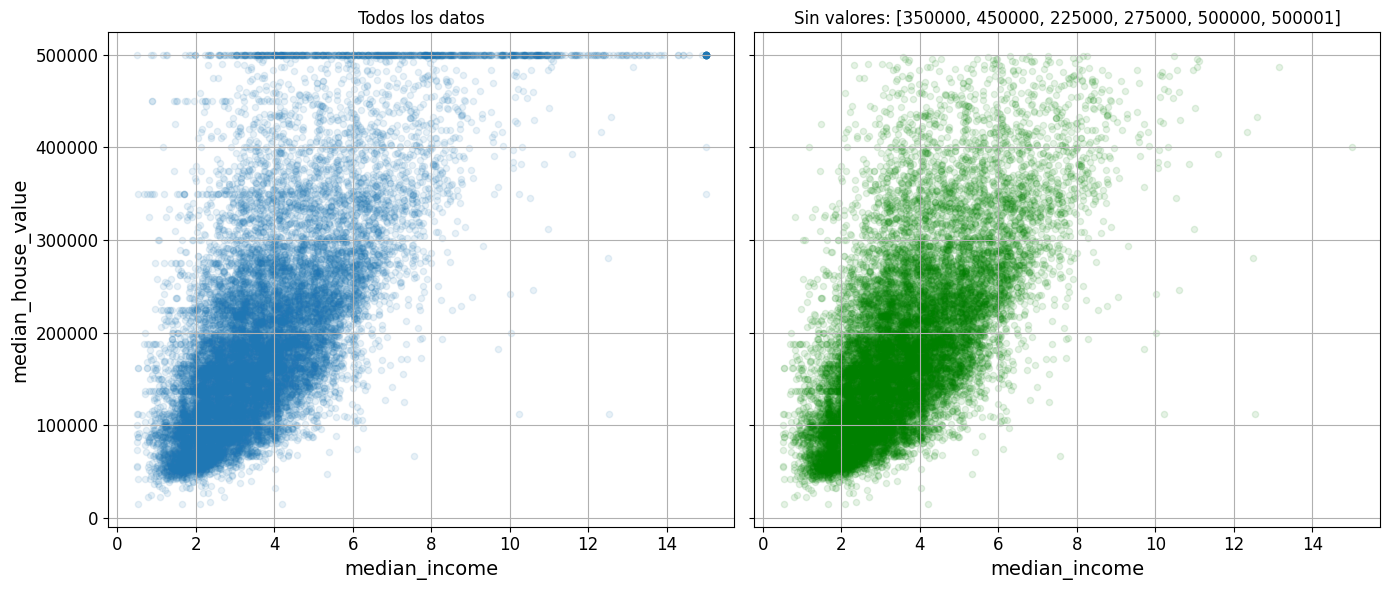

In [60]:
# inicio y final de la comparación
compare_exclusion_effect(housing, exclude_values=[350000, 450000, 225000, 275000, 500000, 500001])

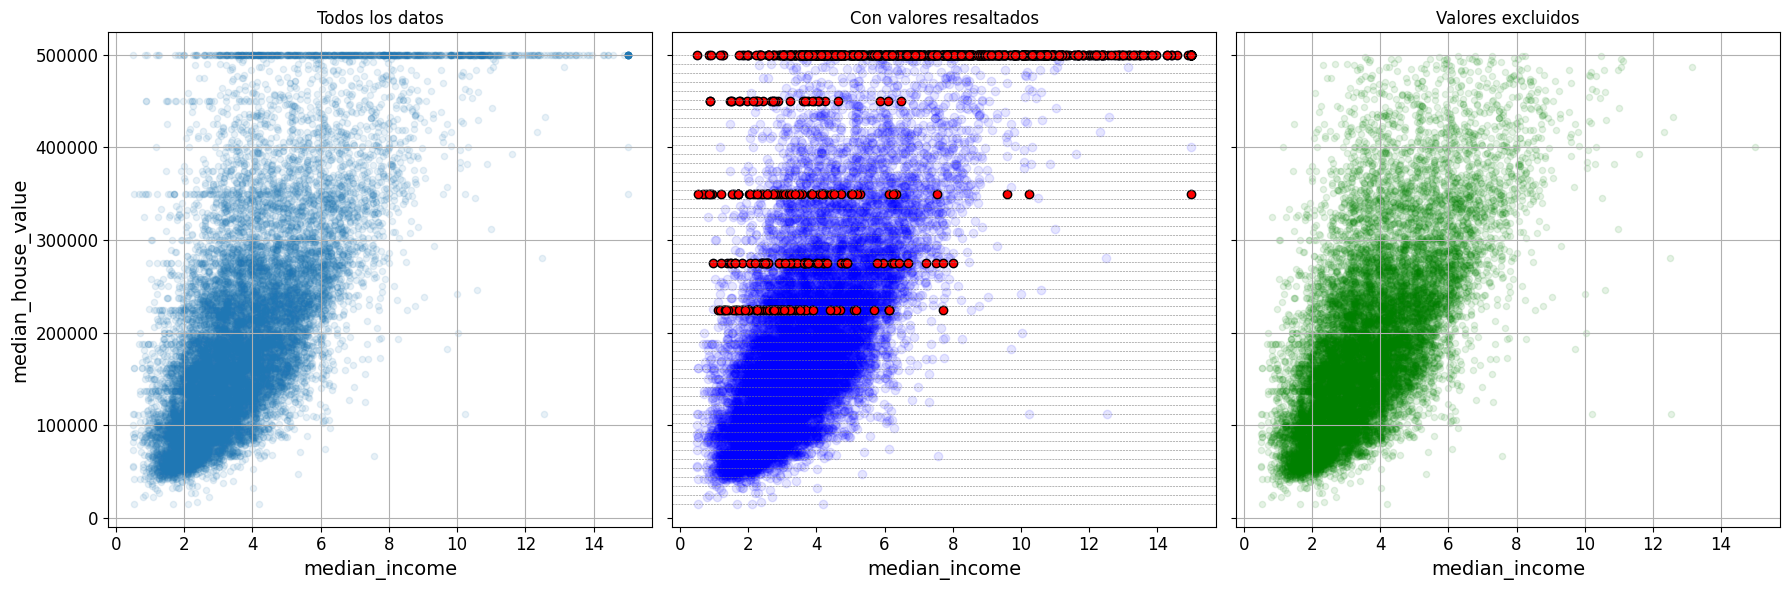

In [61]:
# los tres pasos con inicio, resaltado y final del gráfico de dispersión
compare_three_views(housing, highlight_values=[350000, 450000, 225000, 275000, 500000, 500001])

The correlation coefficient only measures linear correlations (“as x goes up, y generally goes up/down”). It may completely miss out on nonlinear relationships (e.g., “as x approaches 0, y generally goes up”). Figure 2-16 shows a variety of datasets along with their correlation coefficient. Note how all the plots of the bottom row have a correlation coefficient equal to 0, despite the fact that their axes are clearly not independent: these are examples of nonlinear relationships. Also, the second row shows examples where the correlation coefficient is equal to 1 or –1; notice that this has nothing to do with the slope. For example, your height in inches has a correlation coefficient of 1 with your height in feet or in nanometers.

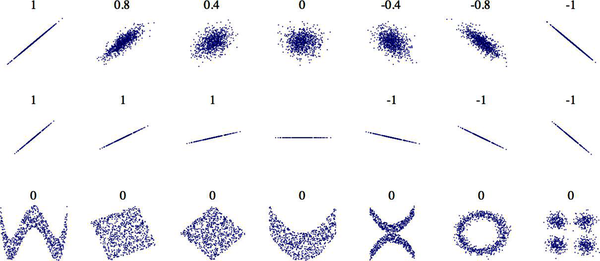
- Figure 2-16

**¿Qué deberías hacer tú en un caso real?**

Si estás haciendo un proyecto real (no siguiendo un ejemplo didáctico), entonces:

- Evalúas la correlación y el significado lógico de nuevos atributos.

- Si aportan valor, los incluyes como parte del pipeline de transformación.

- Documentas qué variables creaste y por qué.

- Evalúas si mejoran el rendimiento del modelo (comparando versiones).

## Experiment with Attribute Combinations

In [62]:
cols_names = strat_train_set.select_dtypes(np.number)
all_attrib = pd.DataFrame()
for i in cols_names:
    for j in cols_names: 
        if i != j:
            nm = i + "_to_" + j
            all_attrib[nm] = strat_train_set[i] / strat_train_set[j]

In [63]:
for a in list(strat_train_set.columns):
    all_attrib[a] = strat_train_set[a]

In [64]:
# pd.set_option('display.max_rows', None)
all_attrib_corr_matrix = all_attrib.corr(numeric_only=True)
all_attrib_corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value                          1.000000
median_house_value_to_latitude              0.994185
longitude_to_median_house_value             0.775685
median_income_to_latitude                   0.689729
median_income                               0.688380
                                              ...   
latitude_to_median_income                  -0.529680
housing_median_age_to_median_house_value   -0.582639
median_income_to_longitude                 -0.685948
latitude_to_median_house_value             -0.764411
median_house_value_to_longitude            -0.999422
Name: median_house_value, Length: 81, dtype: float64

In [65]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

In [66]:
corr_matrix = housing.corr(numeric_only=True)

In [67]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
longitude            -0.050859
latitude             -0.139584
bedrooms_ratio       -0.256397
Name: median_house_value, dtype: float64

# 2.5 Prepare the Data for Machine Learning Algorithms

In [68]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

## Clean the data

- Get rid of the corresponding districts.

- Get rid of the whole attribute.

- Set the missing values to some value (zero, the mean, the median, etc.). This is called imputation.

You decide to go for option 3 since it is the least destructive

Since the median can only be computed on numerical attributes, you then need to create a copy of the data with only the numerical attributes (this will exclude the text attribute ocean_proximity):

In [69]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

Now you can fit the imputer instance to the training data using the fit() method:

In [70]:
housing_num = housing.select_dtypes(include=[np.number])

In [71]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

**El SimpleImputer:**

- Aprende las estadísticas necesarias (fit).

- Luego puede transformar cualquier dataset similar (por ejemplo, el conjunto de test).

- Es esencial para el pipeline de producción, ya que permite mantener consistencia en el preprocesamiento.

In [72]:
imputer.statistics_

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [73]:
housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.    ,  434.    , 1167.    ,
        408.    ,    3.5385])

In [74]:
housing_num.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


Now you can use this “trained” imputer to transform the training set by replacing missing values with the learned medians:

In [75]:
X = imputer.transform(housing_num)

Missing values can also be replaced with the mean value (strategy="mean"), or with the most frequent value (strategy="most_frequent"), or with a constant value (strategy="constant", fill_value=…). The last two strategies support non-numerical data.

There are also more powerful imputers available in the sklearn.impute package (both for numerical features only):

- KNNImputer replaces each missing value with the mean of the k-nearest neighbors’ values for that feature. The distance is based on all the available features.

- IterativeImputer trains a regression model per feature to predict the missing values based on all the other available features. It then trains the model again on the updated data, and repeats the process several times, improving the models and the replacement values at each iteration.

    

In [76]:
housing_tr = pd.DataFrame(X, 
                          columns=housing_num.columns,
                          index=housing_num.index)

In [77]:
housing_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


## Handling Text and Categorical Attributes

In [78]:
housing_cat = housing[["ocean_proximity"]]

In [79]:
housing_cat.head(8)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY


In [80]:
housing_cat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 1 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ocean_proximity  16512 non-null  object
dtypes: object(1)
memory usage: 258.0+ KB


In [81]:
housing_cat["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

Most machine learning algorithms prefer to work with numbers, so let’s convert these categories

In [82]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)

In [83]:
housing_cat_encoded[:8]

array([[3.],
       [0.],
       [1.],
       [1.],
       [4.],
       [1.],
       [0.],
       [3.]])

In [84]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [85]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat, )

In [86]:
housing_cat_1hot

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16512 stored elements and shape (16512, 5)>

In [87]:
housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [88]:
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [89]:
df_test = pd.DataFrame({"ocean_proximity": ["INLAND", "NEAR BAY"]})

In [90]:
pd.get_dummies(df_test)

,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,True,False
1,False,True


In [91]:
cat_encoder.transform(df_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2 stored elements and shape (2, 5)>

In [92]:
df_test_unknown = pd.DataFrame({"ocean_proximity": ["<2H OCEAN", "ISLAND"]})

In [93]:
cat_encoder.handle_unknown = "ignore"

In [94]:
cat_encoder.transform(df_test_unknown)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1 stored elements and shape (2, 5)>

In [95]:
cat_encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [96]:
cat_encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [97]:
#df_output = pd.DataFrame(cat_encoder.transform(df_test_unknown),
#                         columns=cat_encoder.get_feature_names_out(),
#                         index=df_test_unknown.index)

## Feature Scaling and Transformation

In [98]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  object 
dtypes: float64(8), object(1)
memory usage: 1.3+ MB


In [99]:
housing_num.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100


In [100]:
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
housing_num_min_max_scaled = min_max_scaler.fit_transform(housing_num)

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

$$
x_{\text{scaled}} = a + \left( \frac{x - x_{\min}}{x_{\max} - x_{\min}} \right)(b - a)
$$

In [101]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
housing_num_std_scaled = std_scaler.fit_transform(housing_num)

$$
x_{\text{standardized}} = \frac{x - \mu}{\sigma}
$$


Saving figure long_tail_plot


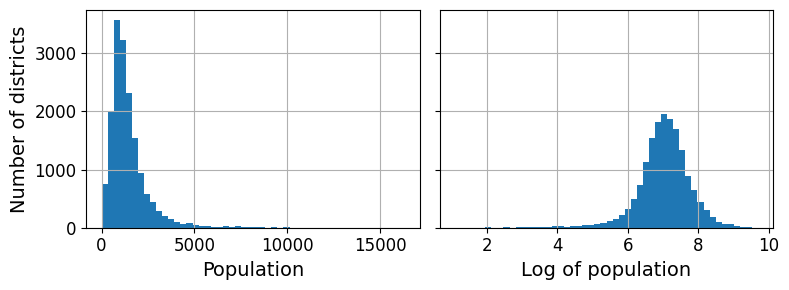

In [102]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

$$
\mathrm{exp}(-\gamma(x-c)^2)
$$

What if we replace each value with its percentile?

In [103]:
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]

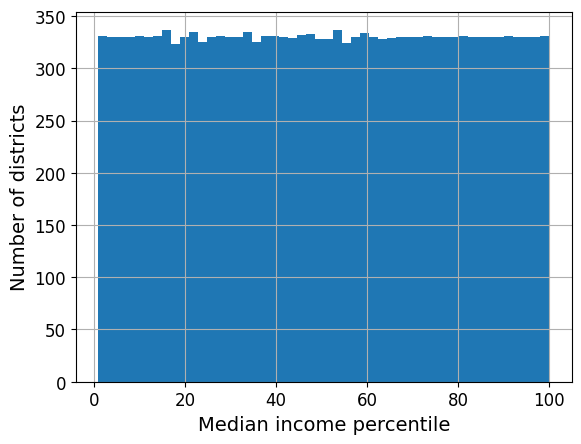

In [104]:
# extra code – just shows that we get a uniform distribution
percentiles = [np.percentile(housing["median_income"], p)
               for p in range(1, 100)]
flattened_median_income = pd.cut(housing["median_income"],
                                 bins=[-np.inf] + percentiles + [np.inf],
                                 labels=range(1, 100 + 1))
flattened_median_income.hist(bins=50)
plt.xlabel("Median income percentile")
plt.ylabel("Number of districts")
plt.show()
# Note: incomes below the 1st percentile are labeled 1, and incomes above the
# 99th percentile are labeled 100. This is why the distribution below ranges
# from 1 to 100 (not 0 to 100).

donde:

- $𝑥$ es la variable de entrada.

- $c$ es el centro de la función (pico de la campana de Gauss).

- $\gamma$ controla el "ancho" de la curva (inversamente proporcional a la varianza).

In [105]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

Saving figure age_similarity_plot


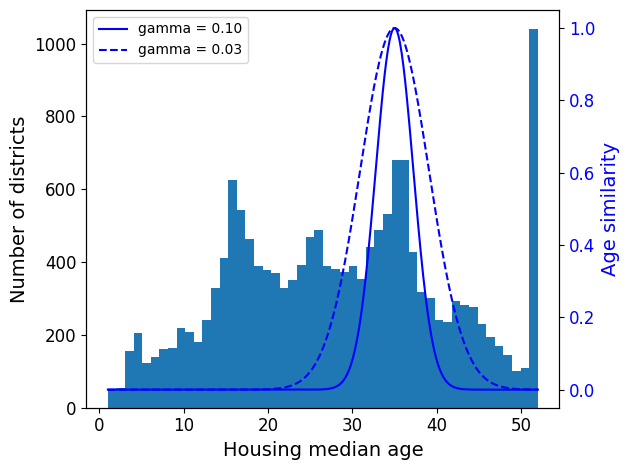

In [106]:
# extra code – this cell generates Figure 2–18

ages = np.linspace(housing["housing_median_age"].min(),
                   housing["housing_median_age"].max(),
                   500).reshape(-1, 1)
gamma1 = 0.1
gamma2 = 0.03
rbf1 = rbf_kernel(ages, [[35]], gamma=gamma1)
rbf2 = rbf_kernel(ages, [[35]], gamma=gamma2)

fig, ax1 = plt.subplots()

ax1.set_xlabel("Housing median age")
ax1.set_ylabel("Number of districts")
ax1.hist(housing["housing_median_age"], bins=50)

ax2 = ax1.twinx()  # create a twin axis that shares the same x-axis
color = "blue"
ax2.plot(ages, rbf1, color=color, label="gamma = 0.10")
ax2.plot(ages, rbf2, color=color, label="gamma = 0.03", linestyle="--")
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylabel("Age similarity", color=color)

plt.legend(loc="upper left")
save_fig("age_similarity_plot")
plt.show()

## Custom Transformers

In [107]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

## Transformation Pipelines